1. 整合part1-part8 + 畫頻譜圖

In [19]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 基本設定
# =========================
INPUT_JSON_PARTS = [
    "./ORMongodb.GTECHDaqRawData.json.part1",
    "./ORMongodb.GTECHDaqRawData.json.part2",
    "./ORMongodb.GTECHDaqRawData.json.part3",
    "./ORMongodb.GTECHDaqRawData.json.part4",
    "./ORMongodb.GTECHDaqRawData.json.part5",
    "./ORMongodb.GTECHDaqRawData.json.part6",
    "./ORMongodb.GTECHDaqRawData.json.part7",
    "./ORMongodb.GTECHDaqRawData.json.part8",
]

OUTPUT_CSV = "spectrum_features_all_parts.csv"
OUTPUT_PLOT_DIR = "spectrum_plots_all_parts"

EXPECTED_LEN = 51200
SAMPLING_RATE_DEFAULT = 51200

# 頻帶設定（可依你的資料調整）
BANDS = [
    ("band_0_20", 0, 20),
    ("band_20_100", 20, 100),
    ("band_100_1000", 100, 1000),
    ("band_1000_5000", 1000, 5000),
    ("band_5000_10000", 5000, 10000),
    ("band_10000_20000", 10000, 20000),
]

TOPK_PEAKS = 5


# =========================
# 工具函式
# =========================
def safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def rms(x):
    x = np.asarray(x, dtype=np.float64)
    if len(x) == 0:
        return np.nan
    return np.sqrt(np.mean(x ** 2))


def get_id_oid(record):
    """
    支援：
    {"_id": {"$oid": "..."}}
    或
    {"_id": "..."}
    """
    try:
        x = record.get("_id", None)
        if isinstance(x, dict):
            return x.get("$oid")
        return x
    except Exception:
        return None


def get_channel_values_and_fs(record, channel_num):
    arr = record.get("DaqRawDataValues", [])
    for item in arr:
        if item.get("EnumChannel") == channel_num:
            values = item.get("Values", [])
            fs = item.get("SamplingRate", SAMPLING_RATE_DEFAULT)
            return np.array([safe_float(v) for v in values], dtype=np.float64), fs
    return np.array([], dtype=np.float64), SAMPLING_RATE_DEFAULT


def get_channel_values_len(record, channel_num):
    arr = record.get("DaqRawDataValues", [])
    for item in arr:
        if item.get("EnumChannel") == channel_num:
            values = item.get("Values", [])
            if isinstance(values, list):
                return len(values)
            return 0
    return 0


def is_valid_record(record, expected_len=51200):
    """
    合格條件：
    1. 有 _id
    2. CH1 的 Values 長度 = expected_len
    3. CH2 的 Values 長度 = expected_len
    """
    oid = get_id_oid(record)
    ch1_len = get_channel_values_len(record, 1)
    ch2_len = get_channel_values_len(record, 2)

    return (oid is not None) and (ch1_len == expected_len) and (ch2_len == expected_len)


def looks_like_target_record(obj):
    """
    避免把巢狀的小 dict 當成 record。
    真正要的 record 至少要有：
    - _id
    - DaqRawDataValues
    """
    return isinstance(obj, dict) and ("_id" in obj) and ("DaqRawDataValues" in obj)


# =========================
# 多檔連續文字流 reader
# 把 part1...part8 當成同一條文字流
# =========================
def iter_chars_from_files(filepaths, chunk_size=1024 * 1024):
    for fp in filepaths:
        path = Path(fp)
        if not path.exists():
            raise FileNotFoundError(f"找不到檔案: {fp}")

        print(f"開始讀取: {fp}")
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                for ch in chunk:
                    yield ch


def iter_complete_json_objects_across_files(filepaths, chunk_size=1024 * 1024):
    """
    把多個 part 檔當成同一條連續文字流，
    掃描完整的 {...} JSON object。

    優點：
    - partN 結尾殘缺 + partN+1 開頭續接，可以拼回完整 object
    - 不需要先手動合併大檔
    - 不依賴最外層一定是合法 JSON array 開頭
    """
    in_string = False
    escape = False
    depth = 0
    collecting = False
    buf = []

    for ch in iter_chars_from_files(filepaths, chunk_size=chunk_size):
        if collecting:
            buf.append(ch)

        if in_string:
            if escape:
                escape = False
            elif ch == "\\":
                escape = True
            elif ch == '"':
                in_string = False
            continue

        if ch == '"':
            in_string = True
            continue

        if ch == "{":
            if depth == 0:
                collecting = True
                buf = ["{"]
            depth += 1
            continue

        if ch == "}":
            if depth > 0:
                depth -= 1

            if depth == 0 and collecting:
                obj_str = "".join(buf)
                collecting = False
                buf = []

                try:
                    obj = json.loads(obj_str)
                    if isinstance(obj, dict):
                        yield obj
                except json.JSONDecodeError:
                    # 不是合法完整 object，略過
                    pass
            continue


# =========================
# 頻譜分析
# =========================
def compute_spectrum(x, fs):
    """
    回傳單邊頻譜：
    freqs: 頻率軸
    mag: amplitude spectrum
    power: power spectrum
    """
    x = np.asarray(x, dtype=np.float64)
    if len(x) == 0:
        return np.array([]), np.array([]), np.array([])

    x = x - np.mean(x)  # 去 DC
    n = len(x)

    fft_vals = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)

    mag = np.abs(fft_vals)
    power = mag ** 2
    return freqs, mag, power


def spectral_entropy(power):
    power = np.asarray(power, dtype=np.float64)
    if len(power) == 0:
        return np.nan
    s = np.sum(power)
    if s <= 0:
        return 0.0
    p = power / s
    p = p[p > 0]
    return -np.sum(p * np.log2(p))


def top_k_peaks(freqs, mag, k=5, skip_dc=True):
    if len(freqs) == 0 or len(mag) == 0:
        return []

    start_idx = 1 if skip_dc and len(freqs) > 1 else 0
    freqs2 = freqs[start_idx:]
    mag2 = mag[start_idx:]

    if len(mag2) == 0:
        return []

    idx_sorted = np.argsort(mag2)[::-1][:k]
    peaks = [(freqs2[i], mag2[i]) for i in idx_sorted]
    peaks = sorted(peaks, key=lambda x: x[1], reverse=True)
    return peaks


def band_energy(freqs, power, f_low, f_high):
    mask = (freqs >= f_low) & (freqs < f_high)
    if not np.any(mask):
        return 0.0
    return np.sum(power[mask])


def extract_spectrum_features(x, fs, prefix="ch1"):
    feats = {}
    freqs, mag, power = compute_spectrum(x, fs)

    if len(freqs) == 0:
        return feats, freqs, mag, power

    total_power = np.sum(power) + 1e-12

    feats[f"{prefix}_spec_len"] = len(mag)
    feats[f"{prefix}_spec_mean"] = np.mean(mag)
    feats[f"{prefix}_spec_std"] = np.std(mag)
    feats[f"{prefix}_spec_max"] = np.max(mag)
    feats[f"{prefix}_spec_rms"] = rms(mag)

    if len(mag) > 1:
        idx_peak = np.argmax(mag[1:]) + 1
    else:
        idx_peak = np.argmax(mag)

    feats[f"{prefix}_dom_freq"] = freqs[idx_peak]
    feats[f"{prefix}_dom_mag"] = mag[idx_peak]
    feats[f"{prefix}_dom_power_ratio"] = power[idx_peak] / total_power

    weighted_sum = np.sum(freqs * power)
    centroid = weighted_sum / total_power
    feats[f"{prefix}_spec_centroid"] = centroid
    feats[f"{prefix}_spec_bandwidth"] = np.sqrt(
        np.sum(((freqs - centroid) ** 2) * power) / total_power
    )

    feats[f"{prefix}_spec_entropy"] = spectral_entropy(power)

    for band_name, f_low, f_high in BANDS:
        e = band_energy(freqs, power, f_low, f_high)
        feats[f"{prefix}_{band_name}_energy"] = e
        feats[f"{prefix}_{band_name}_ratio"] = e / total_power

    low_e = band_energy(freqs, power, 0, 1000)
    high_e = band_energy(freqs, power, 1000, freqs[-1] + 1)
    feats[f"{prefix}_low_high_energy_ratio"] = low_e / (high_e + 1e-12)

    peaks = top_k_peaks(freqs, mag, k=TOPK_PEAKS, skip_dc=True)
    for i in range(TOPK_PEAKS):
        if i < len(peaks):
            f, m = peaks[i]
            feats[f"{prefix}_peak{i+1}_freq"] = f
            feats[f"{prefix}_peak{i+1}_mag"] = m
        else:
            feats[f"{prefix}_peak{i+1}_freq"] = np.nan
            feats[f"{prefix}_peak{i+1}_mag"] = np.nan

    return feats, freqs, mag, power


def extract_cross_spectrum_features(freqs1, mag1, power1, freqs2, mag2, power2):
    feats = {}
    if len(freqs1) == 0 or len(freqs2) == 0:
        return feats

    n = min(len(mag1), len(mag2))
    mag1 = mag1[:n]
    mag2 = mag2[:n]
    power1 = power1[:n]
    power2 = power2[:n]

    if np.std(mag1) > 1e-12 and np.std(mag2) > 1e-12:
        feats["ch12_spec_corr"] = np.corrcoef(mag1, mag2)[0, 1]
    else:
        feats["ch12_spec_corr"] = np.nan

    feats["ch12_spec_abs_mean_diff"] = np.mean(np.abs(mag1 - mag2))
    feats["ch12_spec_power_ratio"] = (np.sum(power1) + 1e-12) / (np.sum(power2) + 1e-12)

    return feats


def save_spectrum_plot(freqs1, mag1, freqs2, mag2, save_path, title):
    plt.figure(figsize=(12, 5))

    if len(freqs1) > 0:
        plt.plot(freqs1, mag1, label="CH1")
    if len(freqs2) > 0:
        plt.plot(freqs2, mag2, label="CH2")

    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()


# =========================
# 主流程
# =========================
def main():
    for fp in INPUT_JSON_PARTS:
        if not Path(fp).exists():
            raise FileNotFoundError(f"找不到檔案: {fp}")

    Path(OUTPUT_PLOT_DIR).mkdir(parents=True, exist_ok=True)

    rows = []
    seen_ids = set()

    total_objects_scanned = 0
    candidate_records = 0
    valid_count = 0
    invalid_count = 0
    duplicate_count = 0

    for obj in iter_complete_json_objects_across_files(INPUT_JSON_PARTS):
        total_objects_scanned += 1

        if not looks_like_target_record(obj):
            continue

        candidate_records += 1
        oid = get_id_oid(obj)

        if oid is not None and oid in seen_ids:
            duplicate_count += 1
            continue

        ch1_len = get_channel_values_len(obj, 1)
        ch2_len = get_channel_values_len(obj, 2)

        if not is_valid_record(obj, EXPECTED_LEN):
            invalid_count += 1
            if candidate_records % 50 == 0:
                print(
                    f"候選 record {candidate_records} 筆 | "
                    f"有效 {valid_count} | "
                    f"略過 {invalid_count} | "
                    f"重複 {duplicate_count}"
                )
            continue

        ch1, fs1 = get_channel_values_and_fs(obj, 1)
        ch2, fs2 = get_channel_values_and_fs(obj, 2)

        row = {
            "row_index": valid_count + 1,
            "_id": oid,
            "ch1_exists": 1,
            "ch2_exists": 1,
            "ch1_len_original": ch1_len,
            "ch2_len_original": ch2_len,
            "expected_len": EXPECTED_LEN,
            "ch1_len_ok": int(ch1_len == EXPECTED_LEN),
            "ch2_len_ok": int(ch2_len == EXPECTED_LEN),
            "fs_ch1": fs1,
            "fs_ch2": fs2,
        }

        feats1, freqs1, mag1, power1 = extract_spectrum_features(ch1, fs1, prefix="ch1")
        feats2, freqs2, mag2, power2 = extract_spectrum_features(ch2, fs2, prefix="ch2")

        row.update(feats1)
        row.update(feats2)
        row.update(extract_cross_spectrum_features(freqs1, mag1, power1, freqs2, mag2, power2))

        rows.append(row)
        if oid is not None:
            seen_ids.add(oid)

        plot_name = f"{valid_count+1:03d}_{oid}_spectrum.png"
        plot_path = Path(OUTPUT_PLOT_DIR) / plot_name
        save_spectrum_plot(
            freqs1, mag1,
            freqs2, mag2,
            plot_path,
            title=f"ID={oid} Spectrum"
        )

        valid_count += 1

        if candidate_records % 20 == 0 or valid_count % 20 == 0:
            print(
                f"候選 record {candidate_records} 筆 | "
                f"有效 {valid_count} | "
                f"略過 {invalid_count} | "
                f"重複 {duplicate_count}"
            )

    if valid_count == 0:
        raise RuntimeError(
            "沒有找到任何符合條件的 record。"
            "請確認 8 個 part 檔案的順序正確，且至少有完整的 JSON object，"
            "並包含 _id、CH1、CH2，且兩個 Values 長度都等於 EXPECTED_LEN。"
        )

    df = pd.DataFrame(rows)
    df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

    print("=" * 60)
    print(f"INPUT_JSON_PARTS: {INPUT_JSON_PARTS}")
    print(f"EXPECTED_LEN: {EXPECTED_LEN}")
    print(f"掃描到的完整 JSON objects 數: {total_objects_scanned}")
    print(f"看起來像 record 的候選物件數: {candidate_records}")
    print(f"有效筆數 (自動當作 NUM_IDS): {valid_count}")
    print(f"略過筆數: {invalid_count}")
    print(f"重複 _id 筆數: {duplicate_count}")
    print(f"完成，已輸出: {OUTPUT_CSV}")
    print(f"頻譜圖資料夾: {OUTPUT_PLOT_DIR}")
    print(f"DataFrame shape: {df.shape}")
    print("=" * 60)
    print("你現在等效於：")
    print(f"NUM_IDS = {valid_count}")
    print("=" * 60)
    print(df.iloc[:3, :20])


if __name__ == "__main__":
    main()

開始讀取: ./ORMongodb.GTECHDaqRawData.json.part1
候選 record 20 筆 | 有效 20 | 略過 0 | 重複 0
候選 record 40 筆 | 有效 40 | 略過 0 | 重複 0
候選 record 60 筆 | 有效 60 | 略過 0 | 重複 0
候選 record 80 筆 | 有效 80 | 略過 0 | 重複 0
候選 record 100 筆 | 有效 100 | 略過 0 | 重複 0
候選 record 120 筆 | 有效 120 | 略過 0 | 重複 0
候選 record 140 筆 | 有效 140 | 略過 0 | 重複 0
候選 record 160 筆 | 有效 160 | 略過 0 | 重複 0
候選 record 180 筆 | 有效 180 | 略過 0 | 重複 0
候選 record 200 筆 | 有效 200 | 略過 0 | 重複 0
候選 record 220 筆 | 有效 220 | 略過 0 | 重複 0
候選 record 240 筆 | 有效 240 | 略過 0 | 重複 0
候選 record 260 筆 | 有效 260 | 略過 0 | 重複 0
候選 record 280 筆 | 有效 280 | 略過 0 | 重複 0
候選 record 300 筆 | 有效 300 | 略過 0 | 重複 0
候選 record 320 筆 | 有效 320 | 略過 0 | 重複 0
候選 record 340 筆 | 有效 340 | 略過 0 | 重複 0
開始讀取: ./ORMongodb.GTECHDaqRawData.json.part2
候選 record 360 筆 | 有效 360 | 略過 0 | 重複 0
候選 record 380 筆 | 有效 380 | 略過 0 | 重複 0
候選 record 400 筆 | 有效 400 | 略過 0 | 重複 0
候選 record 420 筆 | 有效 420 | 略過 0 | 重複 0
候選 record 440 筆 | 有效 440 | 略過 0 | 重複 0
候選 record 460 筆 | 有效 460 | 略過 0 | 重複 0
候選 record 480 筆 | 有效 

2. 頻譜圖統計分析

In [21]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# =========================================================
# 基本設定
# =========================================================
INPUT_CSV = "spectrum_features_all_parts.csv"
OUTPUT_DIR = "spectrum_anomaly_all_parts_outputs"

ID_COL = "_id"

# Isolation Forest 參數
IFOREST_RANDOM_STATE = 42
IFOREST_CONTAMINATION = 0.05   # 可改：0.03 / 0.08 / 0.10
IFOREST_N_ESTIMATORS = 300

# Robust Z-score 門檻
ROBUST_Z_THRESHOLD = 3.5       # 整體 robust z 異常判定
VARIABLE_OUTLIER_THRESHOLD = 3.5  # 單一變數是否算離群

# 前處理
DROP_ZERO_VARIANCE = True
REPLACE_INF_AND_NAN = True

# 若你想改用 RobustScaler，可把下面 USE_ROBUST_SCALER 改成 True
USE_ROBUST_SCALER = False


# =========================================================
# 工具函式
# =========================================================
def ensure_output_dir(path_str):
    path = Path(path_str)
    path.mkdir(parents=True, exist_ok=True)
    return path


def safe_numeric_df(df):
    """
    inf/-inf -> NaN
    NaN 用該欄中位數補
    """
    out = df.copy()
    out = out.replace([np.inf, -np.inf], np.nan)

    for c in out.columns:
        if out[c].isna().any():
            med = out[c].median()
            if pd.isna(med):
                med = 0.0
            out[c] = out[c].fillna(med)
    return out


def drop_zero_variance_columns(df):
    std = df.std(axis=0, ddof=0)
    keep_cols = std[std > 0].index.tolist()
    dropped_cols = [c for c in df.columns if c not in keep_cols]
    return df[keep_cols].copy(), dropped_cols


def robust_zscore_matrix(X_df):
    """
    robust z-score:
    z = (x - median) / MAD
    """
    med = X_df.median(axis=0)
    mad = (X_df - med).abs().median(axis=0)

    mad_safe = mad.copy()
    mad_safe[mad_safe < 1e-12] = 1e-12

    z = (X_df - med) / mad_safe
    return z


def standardize_features(X_df):
    """
    預設 StandardScaler
    若 USE_ROBUST_SCALER=True，則用 median / IQR 方式手動做 robust scaling
    """
    if not USE_ROBUST_SCALER:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_df.values)
        X_scaled_df = pd.DataFrame(X_scaled, columns=X_df.columns, index=X_df.index)
        return X_scaled_df, scaler

    # 手動 RobustScaler
    med = X_df.median(axis=0)
    q1 = X_df.quantile(0.25, axis=0)
    q3 = X_df.quantile(0.75, axis=0)
    iqr = q3 - q1
    iqr[iqr < 1e-12] = 1e-12

    X_scaled_df = (X_df - med) / iqr
    return X_scaled_df, {"median": med, "iqr": iqr}


def run_isolation_forest(X_scaled_df, contamination=0.05, random_state=42, n_estimators=300):
    """
    score_samples: 越大越正常
    這裡轉成 anomaly_score = -score_samples
    所以 anomaly_score 越大 = 越異常
    """
    model = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1
    )
    model.fit(X_scaled_df.values)

    score_samples = model.score_samples(X_scaled_df.values)
    anomaly_score = -score_samples

    pred = model.predict(X_scaled_df.values)  # 1 normal, -1 outlier
    is_outlier = (pred == -1).astype(int)

    return anomaly_score, is_outlier, model


def list_outlier_variables_from_robust_z(robust_z_df, threshold):
    """
    對每個 ID，列出 |robust_z| >= threshold 的變數名稱
    """
    abs_z = robust_z_df.abs()

    outlier_var_lists = []
    outlier_var_counts = []

    for i in range(len(abs_z)):
        row = abs_z.iloc[i]
        vars_out = row.index[row >= threshold].tolist()
        outlier_var_lists.append(vars_out)
        outlier_var_counts.append(len(vars_out))

    return outlier_var_lists, outlier_var_counts


def build_spectrum_feature_groups(columns):
    """
    分成 4 組：
    1. spectrum_all
    2. spectrum_ch1
    3. spectrum_ch2
    4. spectrum_cross
    """
    groups = {
        "spectrum_all": [],
        "spectrum_ch1": [],
        "spectrum_ch2": [],
        "spectrum_cross": [],
    }

    meta_cols = {
        "row_index", "_id",
        "ch1_exists", "ch2_exists",
        "ch1_len_original", "ch2_len_original",
        "ch1_len_ok", "ch2_len_ok",
        "fs_ch1", "fs_ch2",
    }

    usable_cols = [c for c in columns if c not in meta_cols]

    groups["spectrum_all"] = usable_cols
    groups["spectrum_ch1"] = [c for c in usable_cols if c.startswith("ch1_")]
    groups["spectrum_ch2"] = [c for c in usable_cols if c.startswith("ch2_")]
    groups["spectrum_cross"] = [c for c in usable_cols if c.startswith("ch12_")]

    return groups


def analyze_one_group(df_base, feature_cols, group_name, output_dir):
    """
    對單一群組做：
    1. 清理
    2. 去零變異
    3. 標準化
    4. IsolationForest
    5. Robust Z-score
    6. 逐變數離群
    7. 輸出結果
    """
    if len(feature_cols) == 0:
        print(f"[WARN] {group_name}: 沒有可用欄位，略過")
        return None

    X = df_base[feature_cols].copy()

    if REPLACE_INF_AND_NAN:
        X = safe_numeric_df(X)

    dropped_zero_var = []
    if DROP_ZERO_VARIANCE:
        X, dropped_zero_var = drop_zero_variance_columns(X)

    if X.shape[1] == 0:
        print(f"[WARN] {group_name}: 去除零變異後沒有欄位，略過")
        return None

    # 1) 標準化
    X_scaled_df, scaler = standardize_features(X)

    # 2) Isolation Forest
    if_score, if_outlier, if_model = run_isolation_forest(
        X_scaled_df,
        contamination=IFOREST_CONTAMINATION,
        random_state=IFOREST_RANDOM_STATE,
        n_estimators=IFOREST_N_ESTIMATORS
    )

    # 3) Robust Z-score
    robust_z = robust_zscore_matrix(X)
    abs_robust_z = robust_z.abs()

    mean_abs_robust_z = abs_robust_z.mean(axis=1)
    max_abs_robust_z = abs_robust_z.max(axis=1)

    robust_outlier = (max_abs_robust_z >= ROBUST_Z_THRESHOLD).astype(int)

    # 4) 逐變數離群
    outlier_var_lists, outlier_var_counts = list_outlier_variables_from_robust_z(
        robust_z, VARIABLE_OUTLIER_THRESHOLD
    )

    # 5) 組結果表
    result_df = pd.DataFrame({
        "row_index": df_base["row_index"].values if "row_index" in df_base.columns else np.arange(len(df_base)) + 1,
        ID_COL: df_base[ID_COL].values,

        f"{group_name}_n_features": X.shape[1],

        f"{group_name}_iforest_score": if_score,
        f"{group_name}_iforest_rank": pd.Series(if_score).rank(method="min", ascending=False).astype(int).values,
        f"{group_name}_iforest_outlier": if_outlier,

        f"{group_name}_mean_abs_robust_z": mean_abs_robust_z.values,
        f"{group_name}_max_abs_robust_z": max_abs_robust_z.values,
        f"{group_name}_robustz_outlier": robust_outlier.values,

        f"{group_name}_variable_outlier_count": outlier_var_counts,
        f"{group_name}_variable_outlier_list": [" | ".join(v) if len(v) > 0 else "" for v in outlier_var_lists],
    })

    # 綜合異常：任一方法異常就算異常
    result_df[f"{group_name}_combined_outlier"] = (
        (result_df[f"{group_name}_iforest_outlier"] == 1) |
        (result_df[f"{group_name}_robustz_outlier"] == 1)
    ).astype(int)

    # 6) 輸出 anomaly_scores
    result_df.to_csv(output_dir / f"{group_name}_anomaly_scores_all_parts.csv", index=False, encoding="utf-8-sig")

    # 7) 輸出標準化特徵
    scaled_with_id = pd.concat(
        [
            df_base[[c for c in ["row_index", ID_COL] if c in df_base.columns]].reset_index(drop=True),
            X_scaled_df.reset_index(drop=True)
        ],
        axis=1
    )
    scaled_with_id.to_csv(output_dir / f"{group_name}_scaled_features_all_parts.csv", index=False, encoding="utf-8-sig")

    # 8) 輸出 robust z matrix
    robust_z_with_id = pd.concat(
        [
            df_base[[c for c in ["row_index", ID_COL] if c in df_base.columns]].reset_index(drop=True),
            robust_z.reset_index(drop=True)
        ],
        axis=1
    )
    robust_z_with_id.to_csv(output_dir / f"{group_name}_robust_z_matrix_all_parts.csv", index=False, encoding="utf-8-sig")

    # 9) 輸出逐 ID 變數離群明細
    variable_outlier_detail_df = pd.DataFrame({
        "row_index": df_base["row_index"].values if "row_index" in df_base.columns else np.arange(len(df_base)) + 1,
        ID_COL: df_base[ID_COL].values,
        "group_name": group_name,
        "variable_outlier_count": outlier_var_counts,
        "variable_outlier_list": [" | ".join(v) if len(v) > 0 else "" for v in outlier_var_lists],
    })
    variable_outlier_detail_df.to_csv(
        output_dir / f"{group_name}_variable_outlier_details_all_parts.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # 10) Top 30
    result_df.sort_values(f"{group_name}_iforest_score", ascending=False).head(30).to_csv(
        output_dir / f"{group_name}_top30_iforest_all_parts.csv",
        index=False,
        encoding="utf-8-sig"
    )

    result_df.sort_values(f"{group_name}_max_abs_robust_z", ascending=False).head(30).to_csv(
        output_dir / f"{group_name}_top30_robustz_all_parts.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print(f"[OK] {group_name}: samples={X.shape[0]}, features={X.shape[1]}")
    return {
        "group_name": group_name,
        "result_df": result_df,
        "used_feature_cols": X.columns.tolist(),
        "dropped_zero_var_cols": dropped_zero_var,
        "variable_outlier_lists": outlier_var_lists,
        "variable_outlier_counts": outlier_var_counts,
    }


# =========================================================
# 主流程
# =========================================================
def main():
    output_dir = ensure_output_dir(OUTPUT_DIR)

    print(f"讀取: {INPUT_CSV}")
    df = pd.read_csv(INPUT_CSV)

    if ID_COL not in df.columns:
        raise ValueError(f"找不到 ID 欄位: {ID_COL}")

    print(f"資料筆數: {len(df)}")
    print(f"欄位數: {len(df.columns)}")

    groups = build_spectrum_feature_groups(df.columns.tolist())

    all_group_result_dfs = []
    summary_rows = []
    per_id_variable_summary = None

    for group_name, feature_cols in groups.items():
        print("=" * 70)
        print(f"開始分析群組: {group_name}")
        print(f"原始欄位數: {len(feature_cols)}")

        result_info = analyze_one_group(df, feature_cols, group_name, output_dir)
        if result_info is None:
            continue

        result_df = result_info["result_df"]
        all_group_result_dfs.append(result_df)

        summary_rows.append({
            "group_name": group_name,
            "n_samples": len(result_df),
            "n_features_used": len(result_info["used_feature_cols"]),
            "n_zero_var_dropped": len(result_info["dropped_zero_var_cols"]),
            "n_iforest_outliers": int(result_df[f"{group_name}_iforest_outlier"].sum()),
            "n_robustz_outliers": int(result_df[f"{group_name}_robustz_outlier"].sum()),
            "n_combined_outliers": int(result_df[f"{group_name}_combined_outlier"].sum()),
            "avg_variable_outlier_count": float(np.mean(result_info["variable_outlier_counts"])),
            "iforest_contamination": IFOREST_CONTAMINATION,
            "robust_z_threshold": ROBUST_Z_THRESHOLD,
            "variable_outlier_threshold": VARIABLE_OUTLIER_THRESHOLD,
            "use_robust_scaler": USE_ROBUST_SCALER,
        })

        tmp = pd.DataFrame({
            "row_index": df["row_index"].values if "row_index" in df.columns else np.arange(len(df)) + 1,
            ID_COL: df[ID_COL].values,
            f"{group_name}_variable_outlier_count": result_info["variable_outlier_counts"],
            f"{group_name}_variable_outlier_list": [
                " | ".join(v) if len(v) > 0 else "" for v in result_info["variable_outlier_lists"]
            ]
        })

        if per_id_variable_summary is None:
            per_id_variable_summary = tmp
        else:
            per_id_variable_summary = per_id_variable_summary.merge(
                tmp, on=["row_index", ID_COL], how="outer"
            )

    if len(all_group_result_dfs) == 0:
        raise RuntimeError("沒有任何群組成功完成分析。")

    # 合併所有 anomaly score
    merged = None
    for rdf in all_group_result_dfs:
        key_cols = [c for c in ["row_index", ID_COL] if c in rdf.columns]
        if merged is None:
            merged = rdf.copy()
        else:
            merged = merged.merge(rdf, on=key_cols, how="outer")

    merged.to_csv(output_dir / "all_spectrum_groups_anomaly_scores_merged_all_parts.csv", index=False, encoding="utf-8-sig")
    pd.DataFrame(summary_rows).to_csv(output_dir / "spectrum_anomaly_summary_all_parts.csv", index=False, encoding="utf-8-sig")

    if per_id_variable_summary is not None:
        per_id_variable_summary.to_csv(
            output_dir / "per_id_spectrum_variable_outlier_summary_all_parts.csv",
            index=False,
            encoding="utf-8-sig"
        )

    print("=" * 70)
    print("完成")
    print(f"輸出資料夾: {output_dir}")
    print("主要檔案：")
    print("- spectrum_anomaly_summary.csv")
    print("- all_spectrum_groups_anomaly_scores_merged.csv")
    print("- per_id_spectrum_variable_outlier_summary.csv")
    print("- spectrum_all_anomaly_scores.csv")
    print("- spectrum_ch1_anomaly_scores.csv")
    print("- spectrum_ch2_anomaly_scores.csv")
    print("- spectrum_cross_anomaly_scores.csv")


if __name__ == "__main__":
    main()

讀取: spectrum_features_all_parts.csv
資料筆數: 2697
欄位數: 82
開始分析群組: spectrum_all
原始欄位數: 72
[OK] spectrum_all: samples=2697, features=69
開始分析群組: spectrum_ch1
原始欄位數: 34
[OK] spectrum_ch1: samples=2697, features=33
開始分析群組: spectrum_ch2
原始欄位數: 34
[OK] spectrum_ch2: samples=2697, features=33
開始分析群組: spectrum_cross
原始欄位數: 3
[OK] spectrum_cross: samples=2697, features=3
完成
輸出資料夾: spectrum_anomaly_all_parts_outputs
主要檔案：
- spectrum_anomaly_summary.csv
- all_spectrum_groups_anomaly_scores_merged.csv
- per_id_spectrum_variable_outlier_summary.csv
- spectrum_all_anomaly_scores.csv
- spectrum_ch1_anomaly_scores.csv
- spectrum_ch2_anomaly_scores.csv
- spectrum_cross_anomaly_scores.csv


3. 頻譜變數萃取畫出時間序列

In [23]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 基本設定
# =========================
INPUT_CSV = "spectrum_features_all_parts.csv"
OUTPUT_DIR = "feature_lineplots_all_parts"

ID_COL = "_id"

# 合併後資料建議用 row_index 保持原始時間順序
SORT_BY_ROW_INDEX = True

# 是否做每個變數自己的 z-score 標準化
# 若要比較 8 個 part 合起來的整體 shape，建議 True
USE_ZSCORE = True

# 不想畫的欄位
EXCLUDE_COLS = [
    "row_index",
    "ch1_exists", "ch2_exists",
    "ch1_len_ok", "ch2_len_ok",
    "fs_ch1", "fs_ch2",
    "ch1_spec_len", "ch2_spec_len",
    "ch1_len_original", "ch2_len_original",
    "expected_len",
]

FIGSIZE = (18, 5)
LINEWIDTH = 1.2
MARKER_SIZE = 2
ROTATE_XLABEL = 90

# 每隔多少個點顯示一個刻度，避免太擠
XTICK_STEP = 200


# =========================
# 小工具
# =========================
def safe_name(s):
    s = str(s)
    s = re.sub(r'[\\/*?:"<>|]', "_", s)
    return s


# =========================
# 讀資料
# =========================
df = pd.read_csv(INPUT_CSV)

# 用 row_index 排序，保持 8 個 part 合併後的時間順序
if SORT_BY_ROW_INDEX and "row_index" in df.columns:
    df = df.sort_values("row_index").reset_index(drop=True)

# x 軸標籤
if "row_index" in df.columns:
    x_labels = df["row_index"].astype(int).astype(str).tolist()
elif ID_COL in df.columns:
    x_labels = df[ID_COL].astype(str).tolist()
else:
    x_labels = [str(i) for i in range(len(df))]

# 只取數值欄位
numeric_df = df.select_dtypes(include=[np.number]).copy()

# 排除不想畫的欄位
feature_cols = [c for c in numeric_df.columns if c not in EXCLUDE_COLS]
X = numeric_df[feature_cols].copy()

# 去掉完全沒變化的欄位
std_mask = X.std(axis=0, ddof=0) > 0
X = X.loc[:, std_mask]
feature_cols = X.columns.tolist()

print(f"Total samples: {len(df)}")
print(f"Total features to plot: {len(feature_cols)}")

# =========================
# 標準化（每個變數各自做，範圍是整份 all_parts）
# =========================
if USE_ZSCORE:
    mean_ = X.mean(axis=0)
    std_ = X.std(axis=0, ddof=0).replace(0, 1.0)
    X_plot = (X - mean_) / std_
    y_label = "Z-score"
    title_suffix = " (global z-score over all parts)"
else:
    X_plot = X.copy()
    y_label = "Value"
    title_suffix = ""

# 建立輸出資料夾
os.makedirs(OUTPUT_DIR, exist_ok=True)

# x 軸
x = np.arange(len(df))

# x tick 顯示
xticks = np.arange(0, len(df), XTICK_STEP)
xtick_labels = [x_labels[i] for i in xticks]

# =========================
# 每個 feature 畫一張圖
# =========================
for idx, feature in enumerate(feature_cols, start=1):
    y = X_plot[feature].values

    plt.figure(figsize=FIGSIZE)
    plt.plot(x, y, linewidth=LINEWIDTH, marker="o", markersize=MARKER_SIZE)

    plt.xticks(xticks, xtick_labels, rotation=ROTATE_XLABEL, fontsize=8)
    plt.xlabel("row_index")
    plt.ylabel(y_label)
    plt.title(f"{feature}{title_suffix}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(OUTPUT_DIR, f"{idx:03d}_{safe_name(feature)}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()

    if idx % 10 == 0 or idx == len(feature_cols):
        print(f"Saved {idx}/{len(feature_cols)}")

print(f"\nDone. All feature plots saved in: {OUTPUT_DIR}")

Total samples: 2697
Total features to plot: 69
Saved 10/69
Saved 20/69
Saved 30/69
Saved 40/69
Saved 50/69
Saved 60/69
Saved 69/69

Done. All feature plots saved in: feature_lineplots_all_parts


熱圖分析

Total samples: 2697
Total features: 69


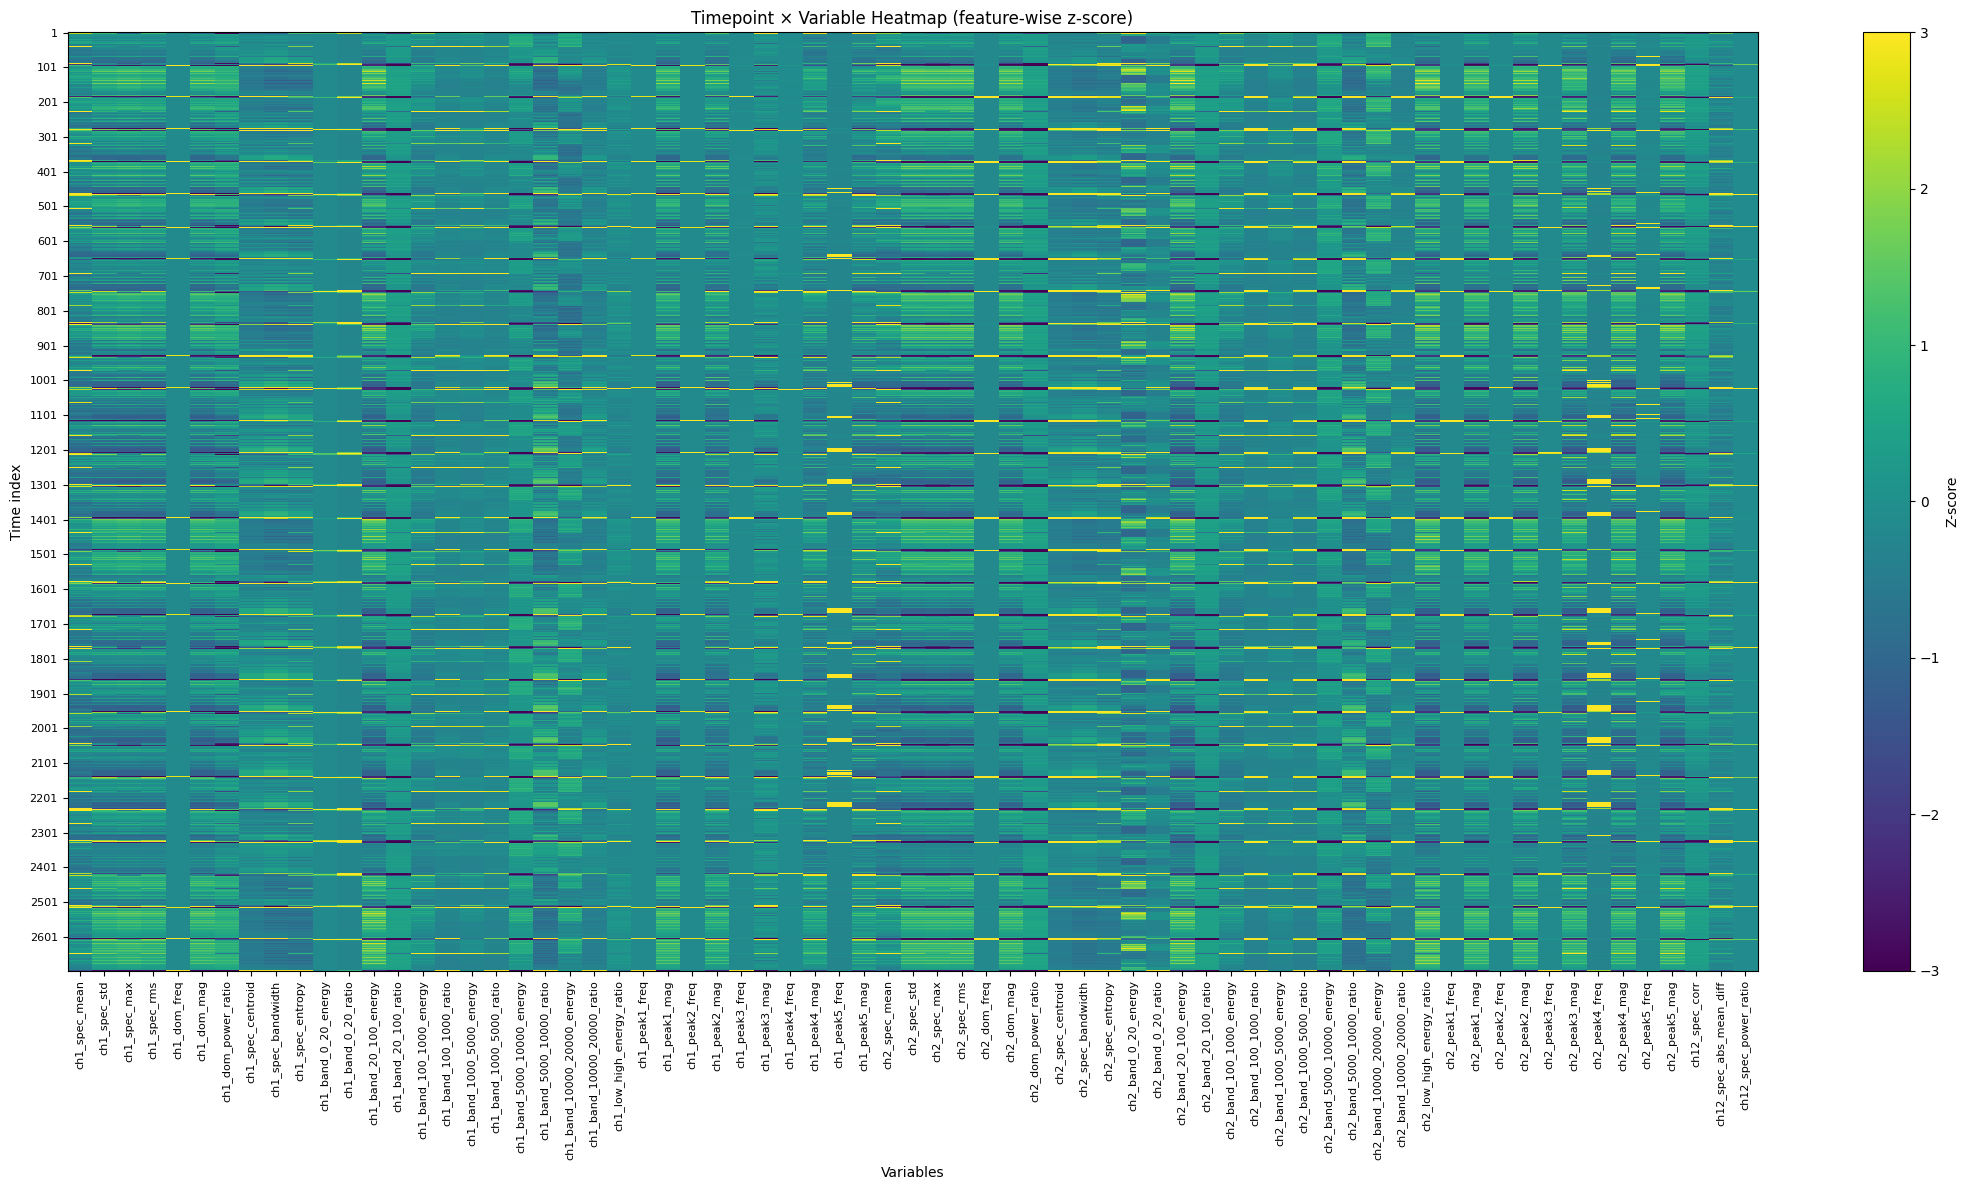

Saved: timepoint_variable_heatmap.png


In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 基本設定
# =========================
INPUT_CSV = "spectrum_features_all_parts.csv"
OUTPUT_PNG = "timepoint_variable_heatmap.png"

ID_COL = "_id"
SORT_BY_ROW_INDEX = False   # 若想照 row_index 排序可改 True
USE_ZSCORE = True           # 建議 True，比較容易看 pattern

EXCLUDE_COLS = [
    "row_index",
    "_id",
    "ch1_exists", "ch2_exists",
    "ch1_len_ok", "ch2_len_ok",
    "fs_ch1", "fs_ch2",
    "ch1_spec_len", "ch2_spec_len",
    "ch1_len_original", "ch2_len_original",
    "expected_len",
]

FIGSIZE = (22, 12)

# 若時間點太多，可選擇是否只顯示部分 y tick
Y_TICK_STEP = 100
X_LABEL_ROTATION = 90


# =========================
# 讀資料
# =========================
df = pd.read_csv(INPUT_CSV)

if SORT_BY_ROW_INDEX and "row_index" in df.columns:
    df = df.sort_values("row_index").reset_index(drop=True)

# 只取數值欄位
numeric_df = df.select_dtypes(include=[np.number]).copy()
feature_cols = [c for c in numeric_df.columns if c not in EXCLUDE_COLS]
X = numeric_df[feature_cols].copy()

# 去除零變異欄位
std_mask = X.std(axis=0, ddof=0) > 0
X = X.loc[:, std_mask]
feature_cols = X.columns.tolist()

print(f"Total samples: {len(X)}")
print(f"Total features: {len(feature_cols)}")

# =========================
# 標準化
# =========================
if USE_ZSCORE:
    mean_ = X.mean(axis=0)
    std_ = X.std(axis=0, ddof=0).replace(0, 1.0)
    X_plot = (X - mean_) / std_
    title_suffix = " (feature-wise z-score)"
else:
    X_plot = X.copy()
    title_suffix = ""

# 轉成矩陣
M = X_plot.values

# =========================
# 畫 heatmap
# =========================
plt.figure(figsize=FIGSIZE)
im = plt.imshow(
    M,
    aspect="auto",
    interpolation="nearest",
    vmin=-3,
    vmax=3,
)

plt.colorbar(im, label="Z-score" if USE_ZSCORE else "Value")

# x 軸：變數
plt.xticks(
    np.arange(len(feature_cols)),
    feature_cols,
    rotation=X_LABEL_ROTATION,
    fontsize=8
)

# y 軸：時間點
y_ticks = np.arange(0, len(X_plot), Y_TICK_STEP)
if "row_index" in df.columns:
    y_tick_labels = df.iloc[y_ticks]["row_index"].astype(int).astype(str).tolist()
else:
    y_tick_labels = [str(i) for i in y_ticks]

plt.yticks(y_ticks, y_tick_labels, fontsize=8)

plt.xlabel("Variables")
plt.ylabel("Time index")
plt.title(f"Timepoint × Variable Heatmap{title_suffix}")
plt.tight_layout()

plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {OUTPUT_PNG}")

Total samples: 2697
Total features: 69
Saved feature mapping: timepoint_variable_heatmap_canvas/feature_id_mapping.csv
Window size = 300
Total windows = 9
Windows shown on canvas = 9


/tmp/ipykernel_3590808/332093508.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.985])


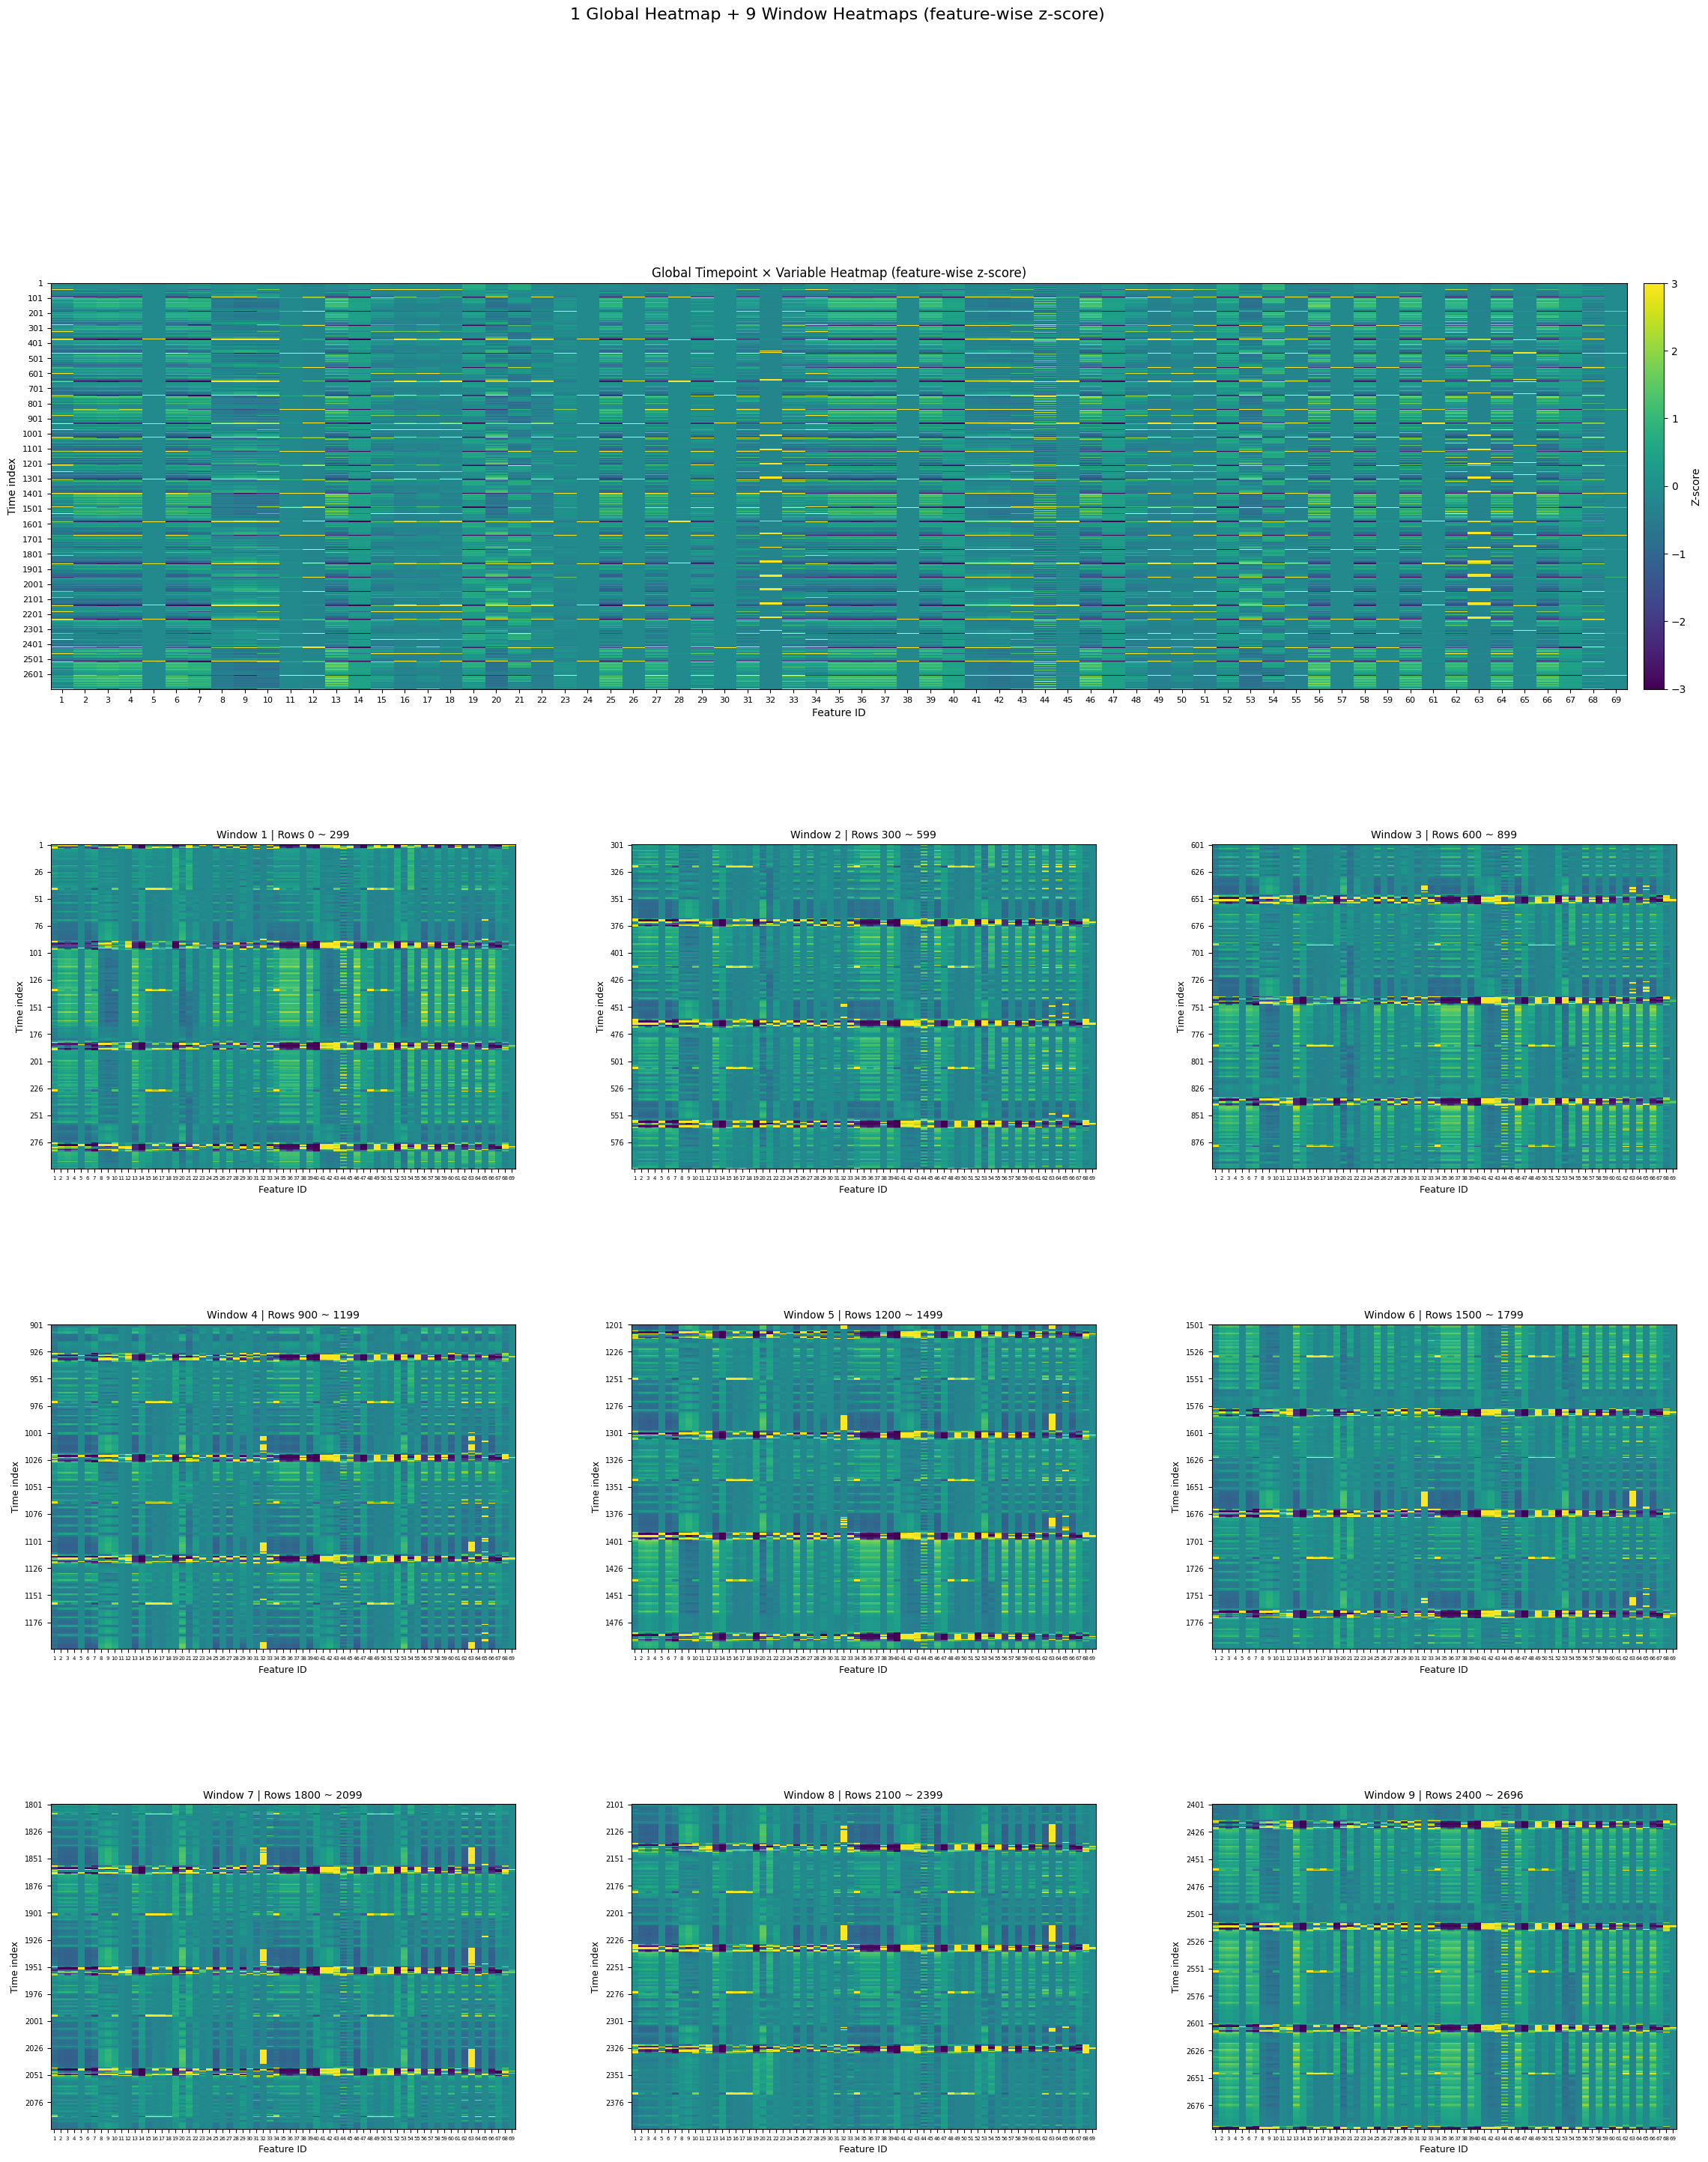

Saved canvas: timepoint_variable_heatmap_canvas/global_plus_9_windows_canvas_numbered.png
Feature ID mapping saved as feature_id_mapping.csv


In [34]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 基本設定
# =========================
INPUT_CSV = "spectrum_features_all_parts.csv"
OUTPUT_DIR = "timepoint_variable_heatmap_canvas"

ID_COL = "_id"
SORT_BY_ROW_INDEX = False   # 若想照 row_index 排序可改 True
USE_ZSCORE = True

EXCLUDE_COLS = [
    "row_index",
    "_id",
    "ch1_exists", "ch2_exists",
    "ch1_len_ok", "ch2_len_ok",
    "fs_ch1", "fs_ch2",
    "ch1_spec_len", "ch2_spec_len",
    "ch1_len_original", "ch2_len_original",
    "expected_len",
]

# 放大畫布
CANVAS_FIGSIZE = (28, 32)

# 顏色範圍
VMIN = -3
VMAX = 3

# 全圖 y 軸刻度
GLOBAL_Y_TICK_STEP = 100

# 切窗設定
WINDOW_SIZE = 300
WINDOW_Y_TICK_STEP = 25


# =========================
# 讀資料
# =========================
df = pd.read_csv(INPUT_CSV)

if SORT_BY_ROW_INDEX and "row_index" in df.columns:
    df = df.sort_values("row_index").reset_index(drop=True)

# 只取數值欄位
numeric_df = df.select_dtypes(include=[np.number]).copy()
feature_cols = [c for c in numeric_df.columns if c not in EXCLUDE_COLS]
X = numeric_df[feature_cols].copy()

# 去除零變異欄位
std_mask = X.std(axis=0, ddof=0) > 0
X = X.loc[:, std_mask]
feature_cols = X.columns.tolist()

print(f"Total samples: {len(X)}")
print(f"Total features: {len(feature_cols)}")

# =========================
# 建立變數編號對照
# =========================
feature_ids = list(range(1, len(feature_cols) + 1))
feature_id_labels = [str(i) for i in feature_ids]

feature_map_df = pd.DataFrame({
    "feature_id": feature_ids,
    "feature_name": feature_cols
})

os.makedirs(OUTPUT_DIR, exist_ok=True)
feature_map_path = os.path.join(OUTPUT_DIR, "feature_id_mapping.csv")
feature_map_df.to_csv(feature_map_path, index=False, encoding="utf-8-sig")
print(f"Saved feature mapping: {feature_map_path}")

# =========================
# 標準化
# =========================
if USE_ZSCORE:
    mean_ = X.mean(axis=0)
    std_ = X.std(axis=0, ddof=0).replace(0, 1.0)
    X_plot = (X - mean_) / std_
    title_suffix = " (feature-wise z-score)"
    cbar_label = "Z-score"
else:
    X_plot = X.copy()
    title_suffix = ""
    cbar_label = "Value"

M = X_plot.values
n_samples = len(X_plot)

# 如果不足 9 個窗，也沒關係；多於 9 個窗，只取前 9 個
n_windows_total = math.ceil(n_samples / WINDOW_SIZE)
n_windows_to_show = min(9, n_windows_total)

print(f"Window size = {WINDOW_SIZE}")
print(f"Total windows = {n_windows_total}")
print(f"Windows shown on canvas = {n_windows_to_show}")

# =========================
# 建大畫布
# =========================
fig = plt.figure(figsize=CANVAS_FIGSIZE)
gs = fig.add_gridspec(
    nrows=4,
    ncols=3,
    height_ratios=[1.25, 1, 1, 1],
    hspace=0.45,
    wspace=0.25
)

# =========================
# 1. 上面全圖
# =========================
ax_global = fig.add_subplot(gs[0, :])

im_global = ax_global.imshow(
    M,
    aspect="auto",
    interpolation="nearest",
    vmin=VMIN,
    vmax=VMAX,
)

# x 軸：變數編號
ax_global.set_xticks(np.arange(len(feature_cols)))
ax_global.set_xticklabels(feature_id_labels, fontsize=8)

# y 軸：時間點
global_y_ticks = np.arange(0, n_samples, GLOBAL_Y_TICK_STEP)
if "row_index" in df.columns:
    global_y_labels = df.iloc[global_y_ticks]["row_index"].astype(int).astype(str).tolist()
else:
    global_y_labels = [str(i) for i in global_y_ticks]

ax_global.set_yticks(global_y_ticks)
ax_global.set_yticklabels(global_y_labels, fontsize=8)

ax_global.set_xlabel("Feature ID")
ax_global.set_ylabel("Time index")
ax_global.set_title(f"Global Timepoint × Variable Heatmap{title_suffix}")

# 全圖 colorbar
cbar_global = fig.colorbar(im_global, ax=ax_global, fraction=0.02, pad=0.01)
cbar_global.set_label(cbar_label)

# =========================
# 2. 下面 9 張切窗
# =========================
for w in range(9):
    ax = fig.add_subplot(gs[1 + w // 3, w % 3])

    # 如果實際不足 9 個窗，後面的格子關掉
    if w >= n_windows_to_show:
        ax.axis("off")
        continue

    start = w * WINDOW_SIZE
    end = min((w + 1) * WINDOW_SIZE, n_samples)
    M_win = M[start:end, :]

    im = ax.imshow(
        M_win,
        aspect="auto",
        interpolation="nearest",
        vmin=VMIN,
        vmax=VMAX,
    )

    # x 軸：變數編號
    ax.set_xticks(np.arange(len(feature_cols)))
    ax.set_xticklabels(feature_id_labels, fontsize=5)

    # y 軸：區段內時間點
    local_y_ticks = np.arange(0, end - start, WINDOW_Y_TICK_STEP)
    if "row_index" in df.columns:
        local_y_labels = df.iloc[start:end].iloc[local_y_ticks]["row_index"].astype(int).astype(str).tolist()
    else:
        local_y_labels = [str(start + i) for i in local_y_ticks]

    ax.set_yticks(local_y_ticks)
    ax.set_yticklabels(local_y_labels, fontsize=7)

    ax.set_xlabel("Feature ID", fontsize=9)
    ax.set_ylabel("Time index", fontsize=9)
    ax.set_title(f"Window {w+1} | Rows {start} ~ {end-1}", fontsize=10)

# =========================
# 輸出
# =========================
fig.suptitle(
    f"1 Global Heatmap + {n_windows_to_show} Window Heatmaps{title_suffix}",
    fontsize=16,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.985])

save_path = os.path.join(OUTPUT_DIR, "global_plus_9_windows_canvas_numbered.png")
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved canvas: {save_path}")
print("Feature ID mapping saved as feature_id_mapping.csv")

Total samples: 2697
Total features: 69
Saved feature mapping: timepoint_variable_heatmap_clustered/feature_id_mapping_reordered.csv
Window size = 300
Total windows = 9
Windows shown on canvas = 9


/tmp/ipykernel_3590808/2404991108.py:229: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.985])


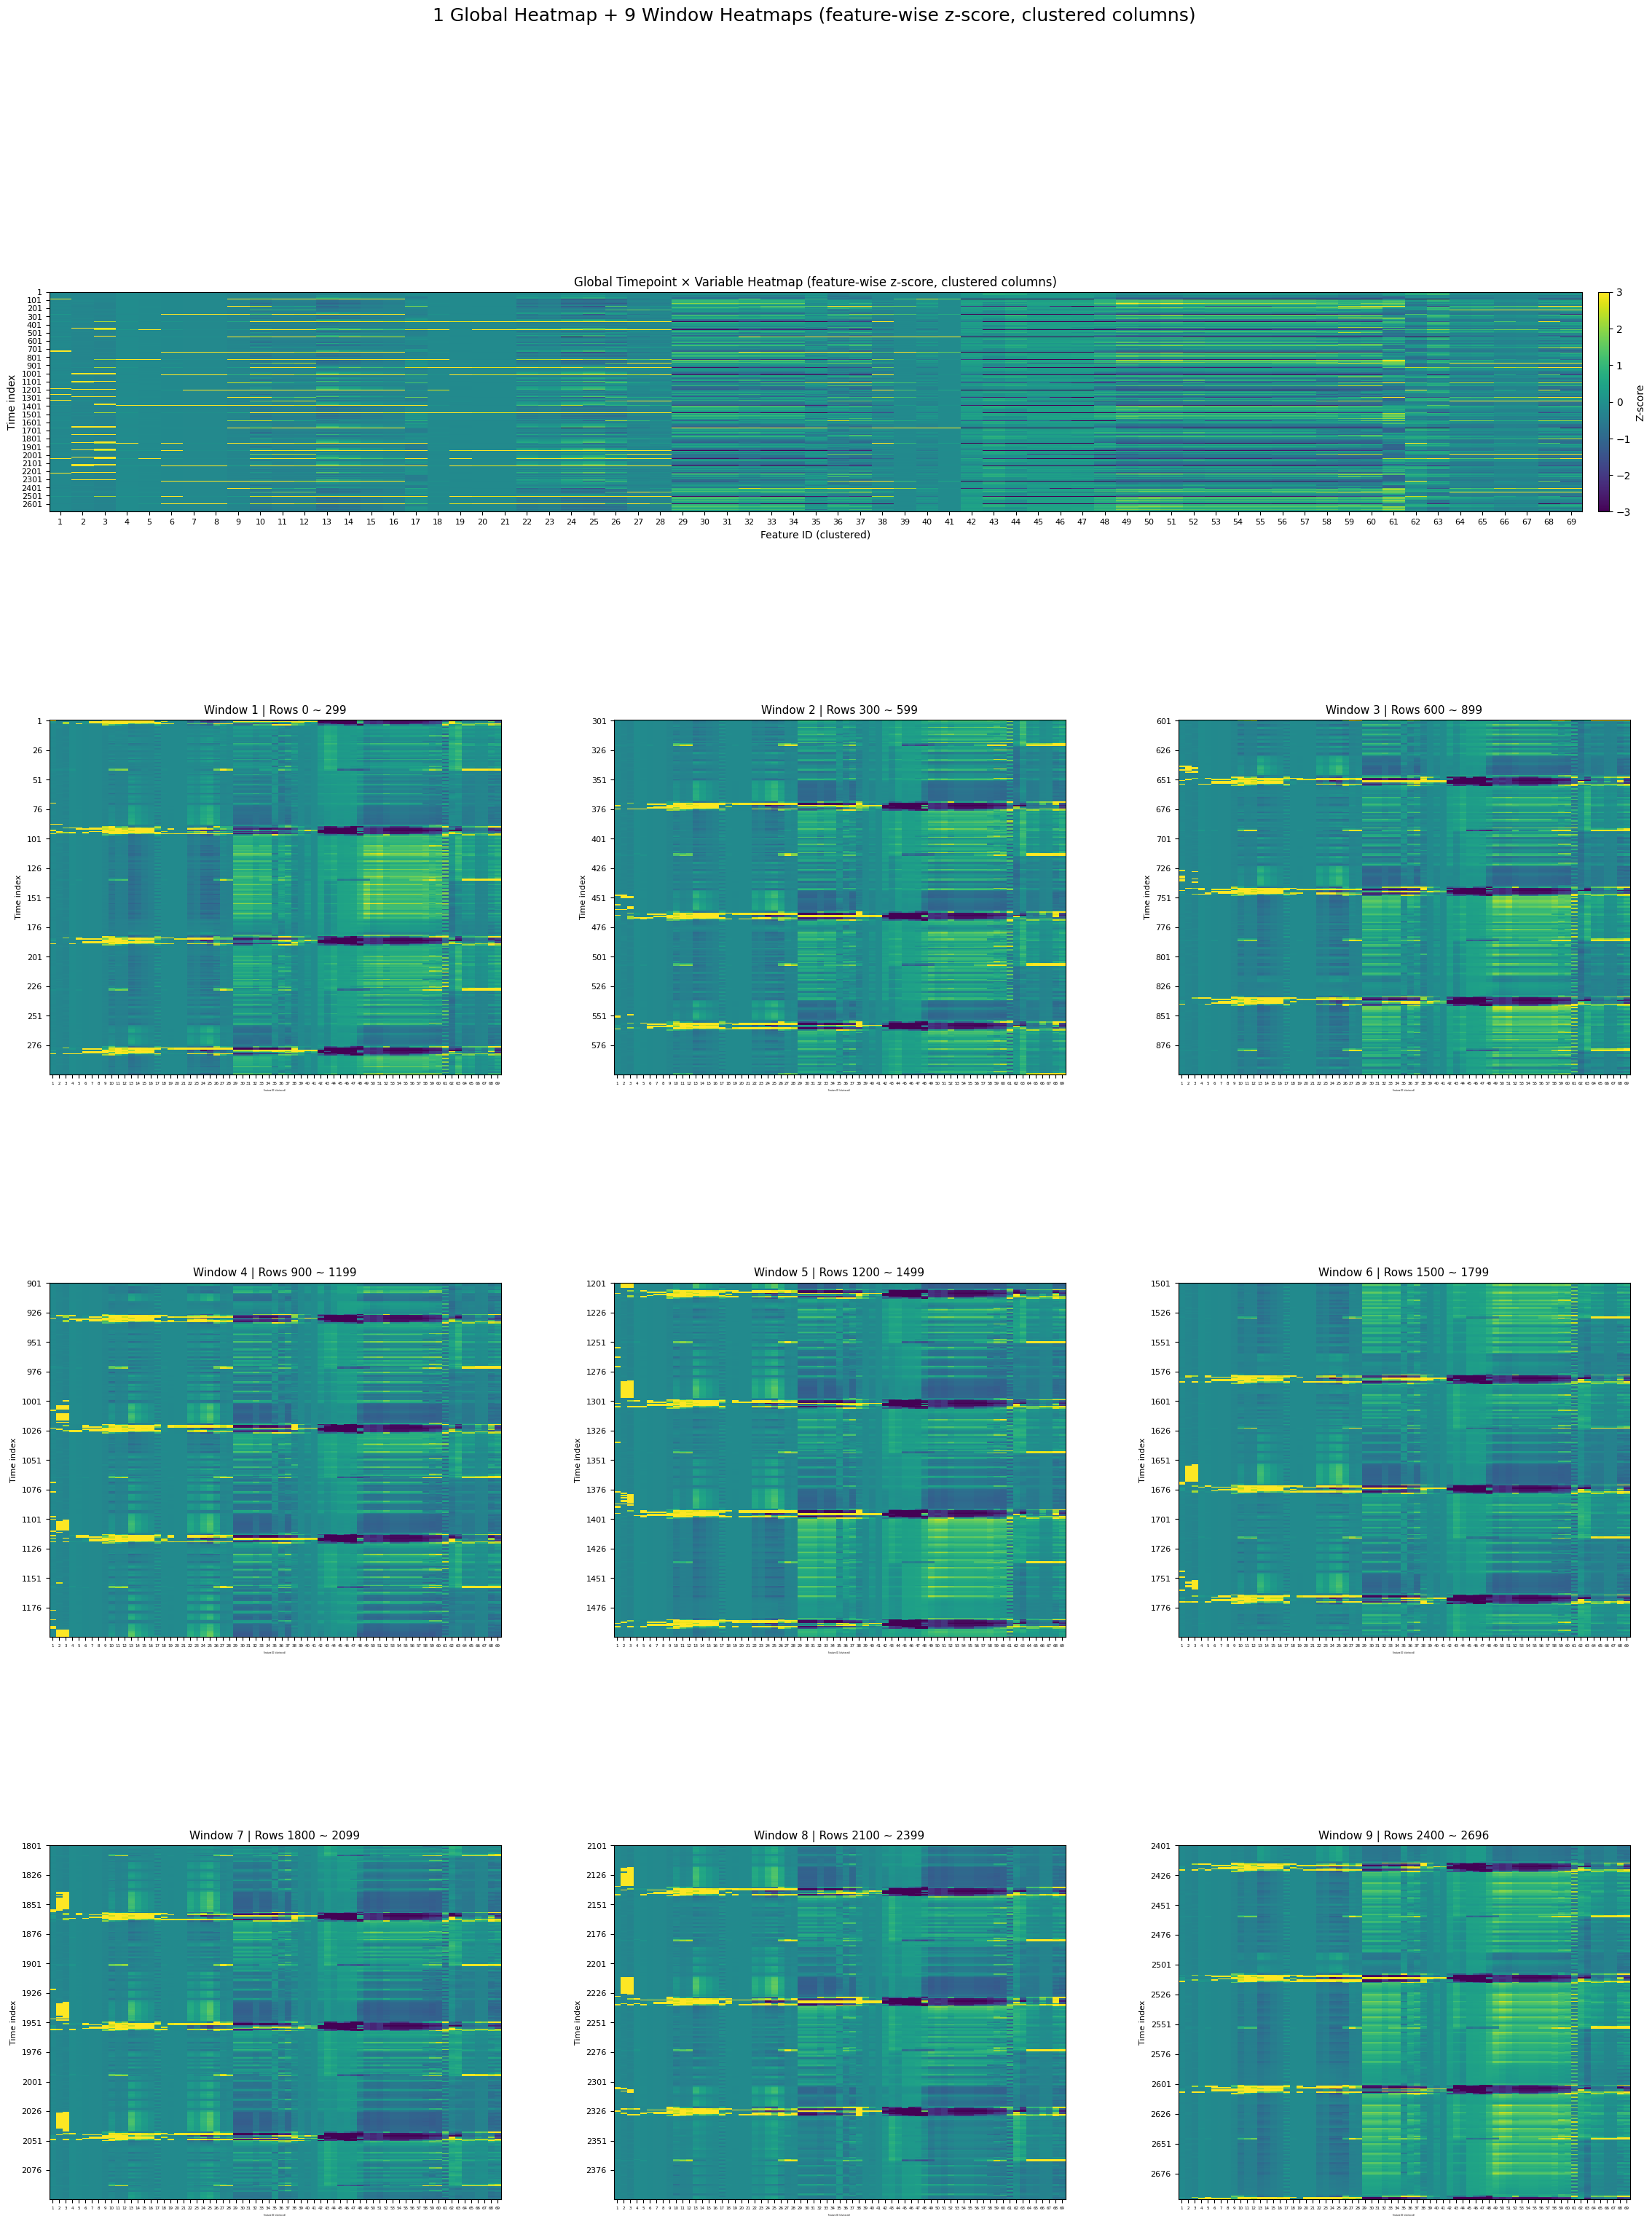

Saved canvas: timepoint_variable_heatmap_clustered/global_plus_9_windows_canvas_clustered.png
Reordered feature mapping saved as feature_id_mapping_reordered.csv


In [40]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# =========================
# 基本設定
# =========================
INPUT_CSV = "spectrum_features_all_parts.csv"
OUTPUT_DIR = "timepoint_variable_heatmap_clustered"

ID_COL = "_id"
SORT_BY_ROW_INDEX = False
USE_ZSCORE = True

EXCLUDE_COLS = [
    "row_index",
    "_id",
    "ch1_exists", "ch2_exists",
    "ch1_len_ok", "ch2_len_ok",
    "fs_ch1", "fs_ch2",
    "ch1_spec_len", "ch2_spec_len",
    "ch1_len_original", "ch2_len_original",
    "expected_len",
]

CANVAS_FIGSIZE = (28, 34)

VMIN = -3
VMAX = 3

GLOBAL_Y_TICK_STEP = 100
WINDOW_SIZE = 300
WINDOW_Y_TICK_STEP = 25

GLOBAL_X_FONTSIZE = 8
GLOBAL_Y_FONTSIZE = 8
WINDOW_X_FONTSIZE = 4
WINDOW_Y_FONTSIZE = 8
GLOBAL_TITLE_FONTSIZE = 12
WINDOW_TITLE_FONTSIZE = 11
SUPTITLE_FONTSIZE = 18

# clustering 參數
# method 可試: "average", "complete", "ward"
LINKAGE_METHOD = "average"


# =========================
# 讀資料
# =========================
df = pd.read_csv(INPUT_CSV)

if SORT_BY_ROW_INDEX and "row_index" in df.columns:
    df = df.sort_values("row_index").reset_index(drop=True)

numeric_df = df.select_dtypes(include=[np.number]).copy()
feature_cols = [c for c in numeric_df.columns if c not in EXCLUDE_COLS]
X = numeric_df[feature_cols].copy()

# 去零變異
std_mask = X.std(axis=0, ddof=0) > 0
X = X.loc[:, std_mask]
feature_cols = X.columns.tolist()

print(f"Total samples: {len(X)}")
print(f"Total features: {len(feature_cols)}")

# =========================
# 標準化
# =========================
if USE_ZSCORE:
    mean_ = X.mean(axis=0)
    std_ = X.std(axis=0, ddof=0).replace(0, 1.0)
    X_plot = (X - mean_) / std_
    title_suffix = " (feature-wise z-score, clustered columns)"
    cbar_label = "Z-score"
else:
    X_plot = X.copy()
    title_suffix = " (clustered columns)"
    cbar_label = "Value"

# =========================
# 對欄位做 clustering 排序
# =========================
# 每一欄是一個變數，拿它在時間上的 26xx 點當成向量
# 用 correlation distance 排序相似變數
# pdist 的輸入是 (n_items, n_features)，所以要轉置
col_matrix = X_plot.T.values  # shape = [n_features, n_timepoints]

# correlation distance = 1 - correlation
dist = pdist(col_matrix, metric="correlation")

# 若某些欄位太平導致 nan，補成 1
dist = np.nan_to_num(dist, nan=1.0, posinf=1.0, neginf=1.0)

Z = linkage(dist, method=LINKAGE_METHOD)
order = leaves_list(Z)

# 重新排序欄位
feature_cols_reordered = [feature_cols[i] for i in order]
X_plot = X_plot[feature_cols_reordered]

# feature id mapping
feature_ids = list(range(1, len(feature_cols_reordered) + 1))
feature_id_labels = [str(i) for i in feature_ids]

os.makedirs(OUTPUT_DIR, exist_ok=True)

feature_map_df = pd.DataFrame({
    "feature_id": feature_ids,
    "feature_name": feature_cols_reordered
})
feature_map_path = os.path.join(OUTPUT_DIR, "feature_id_mapping_reordered.csv")
feature_map_df.to_csv(feature_map_path, index=False, encoding="utf-8-sig")
print(f"Saved feature mapping: {feature_map_path}")

M = X_plot.values
n_samples = len(X_plot)

n_windows_total = math.ceil(n_samples / WINDOW_SIZE)
n_windows_to_show = min(9, n_windows_total)

print(f"Window size = {WINDOW_SIZE}")
print(f"Total windows = {n_windows_total}")
print(f"Windows shown on canvas = {n_windows_to_show}")

# =========================
# 建大畫布
# =========================
fig = plt.figure(figsize=CANVAS_FIGSIZE)
gs = fig.add_gridspec(
    nrows=4,
    ncols=3,
    height_ratios=[0.9, 1.45, 1.45, 1.45],
    hspace=0.65,
    wspace=0.25
)

# =========================
# 1. 上面全圖
# =========================
ax_global = fig.add_subplot(gs[0, :])

im_global = ax_global.imshow(
    M,
    aspect="auto",
    interpolation="nearest",
    vmin=VMIN,
    vmax=VMAX,
)

ax_global.set_xticks(np.arange(len(feature_cols_reordered)))
ax_global.set_xticklabels(feature_id_labels, fontsize=GLOBAL_X_FONTSIZE)

global_y_ticks = np.arange(0, n_samples, GLOBAL_Y_TICK_STEP)
if "row_index" in df.columns:
    global_y_labels = df.iloc[global_y_ticks]["row_index"].astype(int).astype(str).tolist()
else:
    global_y_labels = [str(i) for i in global_y_ticks]

ax_global.set_yticks(global_y_ticks)
ax_global.set_yticklabels(global_y_labels, fontsize=GLOBAL_Y_FONTSIZE)

ax_global.set_xlabel("Feature ID (clustered)")
ax_global.set_ylabel("Time index")
ax_global.set_title(
    f"Global Timepoint × Variable Heatmap{title_suffix}",
    fontsize=GLOBAL_TITLE_FONTSIZE
)

cbar_global = fig.colorbar(im_global, ax=ax_global, fraction=0.02, pad=0.01)
cbar_global.set_label(cbar_label)

# =========================
# 2. 下面 9 張切窗
# =========================
for w in range(9):
    ax = fig.add_subplot(gs[1 + w // 3, w % 3])

    if w >= n_windows_to_show:
        ax.axis("off")
        continue

    start = w * WINDOW_SIZE
    end = min((w + 1) * WINDOW_SIZE, n_samples)
    M_win = M[start:end, :]

    ax.imshow(
        M_win,
        aspect="auto",
        interpolation="nearest",
        vmin=VMIN,
        vmax=VMAX,
    )

    ax.set_xticks(np.arange(len(feature_cols_reordered)))
    ax.set_xticklabels(feature_id_labels, fontsize=WINDOW_X_FONTSIZE)

    local_y_ticks = np.arange(0, end - start, WINDOW_Y_TICK_STEP)
    if "row_index" in df.columns:
        local_y_labels = df.iloc[start:end].iloc[local_y_ticks]["row_index"].astype(int).astype(str).tolist()
    else:
        local_y_labels = [str(start + i) for i in local_y_ticks]

    ax.set_yticks(local_y_ticks)
    ax.set_yticklabels(local_y_labels, fontsize=WINDOW_Y_FONTSIZE)

    ax.set_xlabel("Feature ID (clustered)", fontsize=2)
    ax.set_ylabel("Time index", fontsize=8)
    ax.set_title(
        f"Window {w+1} | Rows {start} ~ {end-1}",
        fontsize=WINDOW_TITLE_FONTSIZE
    )

# =========================
# 輸出
# =========================
fig.suptitle(
    f"1 Global Heatmap + {n_windows_to_show} Window Heatmaps{title_suffix}",
    fontsize=SUPTITLE_FONTSIZE,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.985])

save_path = os.path.join(OUTPUT_DIR, "global_plus_9_windows_canvas_clustered.png")
plt.savefig(save_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved canvas: {save_path}")
print("Reordered feature mapping saved as feature_id_mapping_reordered.csv")